# ⚽ Fotbollsprojekt – VM Slutspel 2026

**Mål:** Analysera VM-matcher och deras resultat.

**Metod:** Skapa matcher, spara i JSON, analysera med klasser och funktioner.

**Verktyg:** Python, JSON, matplotlib

## Importera bibliotek

In [4]:
# Importera bibliotek som behövs för projektet
import json              # Hantera JSON-filer (spara/ladda)
import os                # Kolla om filer finns
import random            # Slumpa data (används inte just nu)
from datetime import datetime  # Hantera datum (används inte just nu)
import matplotlib.pyplot as plt  # Rita diagram

print("✅ Alla bibliotek importerade!")

✅ Alla bibliotek importerade!


## Klasser: VMMatch och SlutspelsMatch

- **VMMatch** – en mall för en VM-match (lag1, lag2, mål, omgång)
- **SlutspelsMatch** – ärver från VMMatch och lägger till förlängning

In [5]:
# ============================================
# STEG 1: VMMatch-klassen
# ============================================
class VMMatch:
    """En klass som representerar en VM-match."""
    
    def __init__(self, lag1, lag2, lag1_mal, lag2_mal, omgång):
        # Spara all information på objektet
        self.lag1 = lag1
        self.lag2 = lag2
        self.lag1_mal = lag1_mal
        self.lag2_mal = lag2_mal
        self.omgång = omgång
    
    def resultat(self):
        # Returnerar matchresultatet som en sträng
        return f"{self.lag1} {self.lag1_mal} - {self.lag2_mal} {self.lag2}"
    
    def vinnare(self):
        # Kollar vem som vann matchen
        if self.lag1_mal > self.lag2_mal:
            return self.lag1
        elif self.lag2_mal > self.lag1_mal:
            return self.lag2
        else:
            return "Oavgjord"
    
    def till_dict(self):
        # Gör om objektet till en dictionary (för JSON)
        return {
            "lag1": self.lag1,
            "lag2": self.lag2,
            "lag1_mal": self.lag1_mal,
            "lag2_mal": self.lag2_mal,
            "omgång": self.omgång
        }
    
    def __str__(self):
        # Bestämmer hur matchen visas vid print()
        return f"[{self.omgång}] {self.resultat()}"


# ============================================
# STEG 2: SlutspelsMatch (arv)
# ============================================
class SlutspelsMatch(VMMatch):
    """En barnklass som ärver från VMMatch och lägger till förlängning."""
    
    def __init__(self, lag1, lag2, lag1_mal, lag2_mal, omgång, förlängning=False):
        # Anropa förälderklassens __init__
        super().__init__(lag1, lag2, lag1_mal, lag2_mal, omgång)
        # Eget attribut
        self.förlängning = förlängning
    
    def till_dict(self):
        # Utöka förälderns till_dict med förlängning
        data = super().till_dict()
        data["förlängning"] = self.förlängning
        return data
    
    def __str__(self):
        # Visa "efter förlängning" om det behövs
        text = super().__str__()
        if self.förlängning:
            text += " (efter förlängning)"
        return text

print("✅ Klasserna VMMatch och SlutspelsMatch är skapade!")

✅ Klasserna VMMatch och SlutspelsMatch är skapade!


### Test av klasserna

In [6]:
test_match = VMMatch("Spanien", "Argentina", 1, 0, "Final")
print(test_match)
print()

test_slutspel = SlutspelsMatch("England", "Norge", 2, 1, "Kvartsfinal", förlängning=True)
print(test_slutspel)

[Final] Spanien 1 - 0 Argentina

[Kvartsfinal] England 2 - 1 Norge (efter förlängning)


## Funktionen skapa_matcher()

Skapar alla 8 VM-matcher från slutspelet 2026 och returnerar dem som en lista.

In [7]:
def skapa_matcher():
    """Skapar alla 8 VM-matcher från slutspelet 2026."""
    # Lista med alla matcher – använder SlutspelsMatch (barnklassen)
    matcher = [
        SlutspelsMatch("Frankrike", "Marocko", 2, 0, "Kvartsfinal", förlängning=False),
        SlutspelsMatch("Spanien", "Belgien", 2, 1, "Kvartsfinal", förlängning=False),
        SlutspelsMatch("England", "Norge", 2, 1, "Kvartsfinal", förlängning=True),
        SlutspelsMatch("Argentina", "Schweiz", 3, 1, "Kvartsfinal", förlängning=True),
        SlutspelsMatch("Spanien", "Frankrike", 2, 0, "Semifinal", förlängning=False),
        SlutspelsMatch("Argentina", "England", 2, 1, "Semifinal", förlängning=False),
        SlutspelsMatch("England", "Frankrike", 6, 4, "Bronsmatch", förlängning=False),
        SlutspelsMatch("Spanien", "Argentina", 1, 0, "Final", förlängning=True)
    ]
    # Returnera listan så den kan användas utanför funktionen
    return matcher

print("✅ Funktionen skapa_matcher() är skapad!")

✅ Funktionen skapa_matcher() är skapad!


### Test av skapa_matcher()

In [8]:
# Anropa funktionen och spara alla matcher i en lista
alla_matcher = skapa_matcher()

# Visa hur många matcher vi har
print("Antal matcher:", len(alla_matcher))
print()

# Loopa igenom alla matcher och skriv ut dem
for match in alla_matcher:
    print(match)

Antal matcher: 8

[Kvartsfinal] Frankrike 2 - 0 Marocko
[Kvartsfinal] Spanien 2 - 1 Belgien
[Kvartsfinal] England 2 - 1 Norge (efter förlängning)
[Kvartsfinal] Argentina 3 - 1 Schweiz (efter förlängning)
[Semifinal] Spanien 2 - 0 Frankrike
[Semifinal] Argentina 2 - 1 England
[Bronsmatch] England 6 - 4 Frankrike
[Final] Spanien 1 - 0 Argentina (efter förlängning)


## Funktionen spara_till_json()

Sparar en lista med matcher till en JSON-fil så att vi kan läsa dem senare.

In [9]:
def spara_till_json(matcher, filnamn="vm_matcher.json"):
    """Sparar en lista med matcher till en JSON-fil."""
    try:
        # Gör om varje match-objekt till en dictionary
        data = [match.till_dict() for match in matcher]
        
        # Öppna filen och skriv datan som JSON
        with open(filnamn, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        
        print(f"✅ {len(matcher)} matcher sparade till {filnamn}")
        return True
    
    except Exception as e:
        # Om något går fel – skriv ut felet
        print(f"❌ Fel vid sparande: {e}")
        return False

print("✅ Funktionen spara_till_json() är skapad!")

✅ Funktionen spara_till_json() är skapad!


### Test av spara_till_json()

In [10]:
# Anropa funktionen och spara resultatet
resultat = spara_till_json(alla_matcher)

# Skriv ut om det lyckades
print("Lyckades?", resultat)

✅ 8 matcher sparade till vm_matcher.json
Lyckades? True


## Funktionen ladda_från_json()

Läser in matcher från en JSON-fil och gör om dem till objekt.

In [11]:
def ladda_från_json(filnamn="vm_matcher.json"):
    """Laddar matcher från en JSON-fil."""
    try:
        # Kolla om filen finns
        if not os.path.exists(filnamn):
            print(f"⚠️ Filen {filnamn} finns inte.")
            return []
        
        # Öppna filen och läs in datan
        with open(filnamn, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        # Skapa en lista med VMMatch-objekt från datan
        matcher = []
        for rad in data:
            match = VMMatch(
                rad["lag1"],
                rad["lag2"],
                rad["lag1_mal"],
                rad["lag2_mal"],
                rad["omgång"]
            )
            matcher.append(match)
        
        print(f"✅ {len(matcher)} matcher laddade från {filnamn}")
        return matcher
    
    except Exception as e:
        # Om något går fel – skriv ut felet
        print(f"❌ Fel vid laddning: {e}")
        return []

print("✅ Funktionen ladda_från_json() är skapad!")

✅ Funktionen ladda_från_json() är skapad!


### Test av ladda_från_json()

In [12]:
# Anropa funktionen och ladda matcherna
laddade_matcher = ladda_från_json()

# Visa hur många matcher som laddades
print("Antal laddade matcher:", len(laddade_matcher))
print()

# Loopa igenom och skriv ut alla matcher
for match in laddade_matcher:
    print(match)

✅ 8 matcher laddade från vm_matcher.json
Antal laddade matcher: 8

[Kvartsfinal] Frankrike 2 - 0 Marocko
[Kvartsfinal] Spanien 2 - 1 Belgien
[Kvartsfinal] England 2 - 1 Norge
[Kvartsfinal] Argentina 3 - 1 Schweiz
[Semifinal] Spanien 2 - 0 Frankrike
[Semifinal] Argentina 2 - 1 England
[Bronsmatch] England 6 - 4 Frankrike
[Final] Spanien 1 - 0 Argentina


## Funktionen beräkna_statistik()

Räknar ut statistik från matcherna: antal matcher, totala mål, medelvärde, max/min.

In [13]:
def beräkna_statistik(matcher):
    """Beräknar statistik från en lista med matcher."""
    # Om listan är tom – returnera tom dictionary
    if not matcher:
        return {}
    
    # Variabler för att samla data
    total_mål = 0
    antal_oavgjorda = 0
    mål_per_match = []
    
    # Loopa igenom varje match
    for match in matcher:
        # Räkna ut totalt antal mål i matchen
        mål = match.lag1_mal + match.lag2_mal
        total_mål += mål
        mål_per_match.append(mål)
        
        # Kolla om matchen var oavgjord
        if match.vinnare() == "Oavgjord":
            antal_oavgjorda += 1
    
    # Sammanställ statistiken i en dictionary
    statistik = {
        "antal_matcher": len(matcher),
        "total_mål": total_mål,
        "medel_mål_per_match": round(total_mål / len(matcher), 2),
        "max_mål": max(mål_per_match),
        "min_mål": min(mål_per_match),
        "antal_oavgjorda": antal_oavgjorda
    }
    
    return statistik

print("✅ Funktionen beräkna_statistik() är skapad!")

✅ Funktionen beräkna_statistik() är skapad!


### Test av beräkna_statistik()

In [14]:
# Anropa funktionen och spara statistiken
statistik = beräkna_statistik(alla_matcher)

# Skriv ut statistiken rad för rad
print("=== STATISTIK ===")
for nyckel, värde in statistik.items():
    print(f"{nyckel}: {värde}")

=== STATISTIK ===
antal_matcher: 8
total_mål: 28
medel_mål_per_match: 3.5
max_mål: 10
min_mål: 1
antal_oavgjorda: 0


## Visualisering

Ritar ett stapeldiagram över antal mål per match.

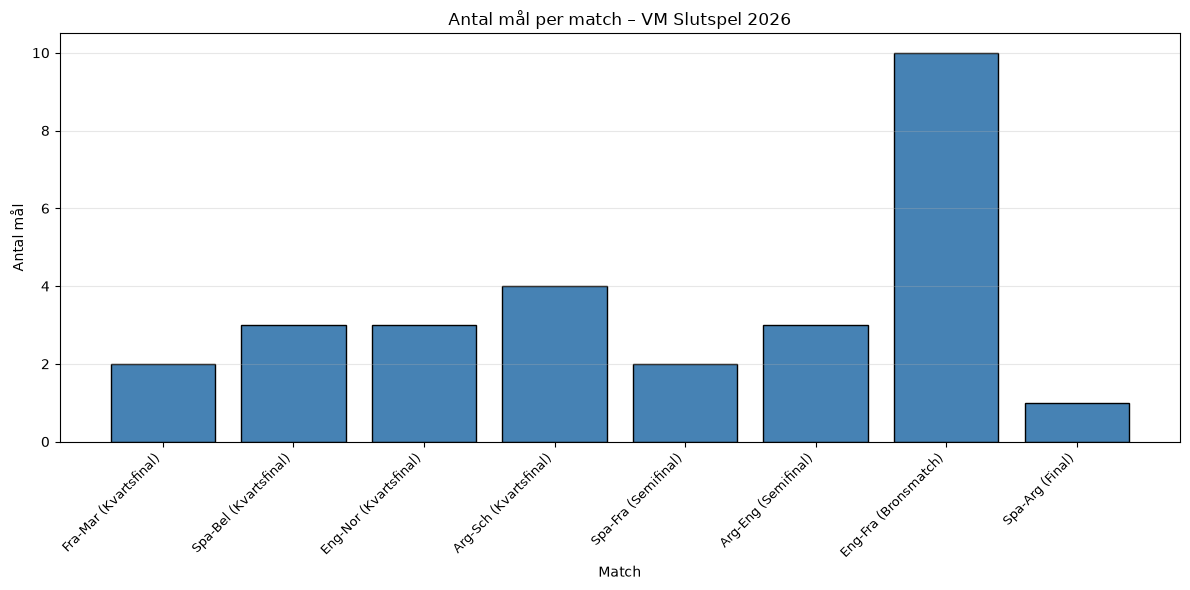

✅ Diagrammet är klart!


In [16]:
# Förbered data för diagrammet
matcher_namn = []   # Lista med matchnamn (t.ex. "Spa-Arg (Final)")
antal_mål = []      # Lista med antal mål per match

# Loopa igenom alla matcher och samla data
for match in alla_matcher:
    # Korta ner lagnamnen till 3 bokstäver + visa omgången
    namn = f"{match.lag1[:3]}-{match.lag2[:3]} ({match.omgång})"
    matcher_namn.append(namn)
    antal_mål.append(match.lag1_mal + match.lag2_mal)

# Skapa diagrammet
plt.figure(figsize=(12, 6))   # Storlek på diagrammet
plt.bar(matcher_namn, antal_mål, color="steelblue", edgecolor="black")

# Lägg till titel och etiketter
plt.title("Antal mål per match – VM Slutspel 2026")
plt.xlabel("Match")
plt.ylabel("Antal mål")
plt.xticks(rotation=45, ha="right", fontsize=9)   # Rotera etiketter
plt.grid(axis="y", alpha=0.3)   # Rutnät på y-axeln

# Visa diagrammet
plt.tight_layout()
plt.show()

print("✅ Diagrammet är klart!")